In [2]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc

In [3]:
import torch
import PINN
from PINN import reader, models, pl, tl

import matplotlib.pyplot as plt

In [4]:
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint

In [5]:
os.chdir("../../")

In [6]:
# CHANG THIS !!!!!
ckpt_path = "logs/tom_pos-DM_scaled_multiBnch/MLP_full_tsense/lightning_logs/version_1/checkpoints/epoch=301-total_loss=0.00000468.ckpt"

# load data

In [7]:
# MODEL CLASS and define model
model_class = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_class}")
mlp_model = model_class.load_from_checkpoint(ckpt_path)
device = mlp_model.device

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


In [8]:
data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].replace("_multiBnch","")

n_timepoint = 7
n_dimension =10

# the DS
DS_t7 = reader.HigDim_AnnDS(AnnData=adata, n_timepoint=n_timepoint,  
                            n_dimension = n_dimension,
                              cellstate_key=cellstate_key,  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False
                              )

In [9]:
t7_ad = DS_t7.adata.copy()
u_b = DS_t7.u_b.cpu().numpy().reshape(n_timepoint, -1)

s_all = DS_t7.s.float().requires_grad_()
t_b = DS_t7.t_b.float().requires_grad_()
cellstate = torch.from_numpy(DS_t7.cellstate).float().requires_grad_()

# ODE solve

In [10]:
from torch import nn

In [10]:
device = mlp_model.device

class Diffusion_equation(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, states):

        u = states[0]
        s = states[1]

        t_in = torch.full((s.shape[0],1), t.item()*5).float().to(device).requires_grad_()


        with torch.set_grad_enabled(True):

            s.requires_grad_(True)
            t_in.requires_grad_(True)

            _, growth, drift, diffuse = self.model.equation(s, t_in)

            dudt = growth + diffuse - drift

            # set ds to zeros to fix cellstates
            ds = torch.zeros_like(s).float().to(device).requires_grad_(True)

        return (dudt, ds)

In [11]:
ode =Diffusion_equation(mlp_model)

# prepare input

In [12]:
timepoints

array([  3,   7,  12,  27,  49,  76, 112, 161, 269])

In [13]:
# t_list
t_list = t7_ad.uns['pop']['t'][:n_timepoint] / 15

print(timepoints[:n_timepoint])
print(t_list)

[  3   7  12  27  49  76 112]
[0.2        0.46666667 0.8        1.8        3.26666667 5.06666667
 7.46666667]


In [14]:
subset_cb = np.random.choice(t7_ad.obs_names, int(0.2*len(t7_ad.obs_names)), replace=False)
subset_ad = t7_ad[subset_cb].copy()

In [15]:
full_cb_list = list(t7_ad.obs_names)
subset_idex = [full_cb_list.index(cb) for cb in subset_cb ]

## init with subset data

In [39]:
s0 = subset_ad.obsm['DM_scaled'][:,:n_dimension]
tompos_u0 = u_b[0, subset_idex]

s0 = torch.from_numpy(s0).float().to(device).requires_grad_()
tompos_u0 = torch.from_numpy(tompos_u0).float().to(device).requires_grad_()

init_condition = (tompos_u0, s0)

prediction of shape (7, 5189)


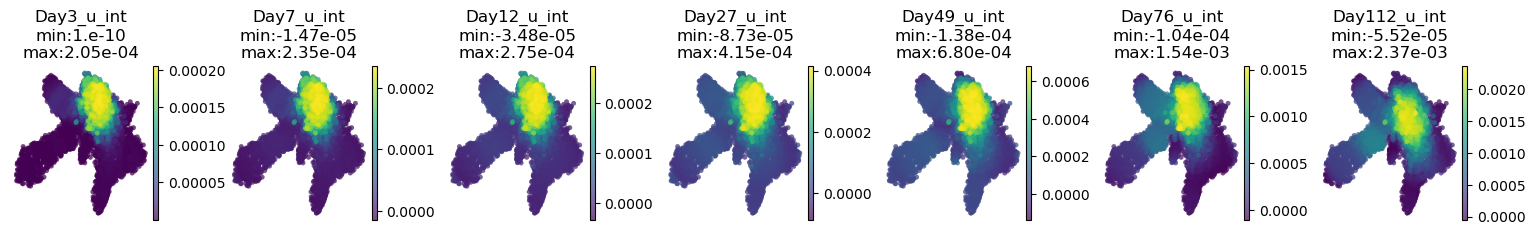

In [ ]:
PINN.pl.params_in_umap(subset_ad, u_t, param='u_int', cell_of_t=False);

## init with the whole h5 data

In [16]:

s0 = cellstate.to(device)
tompos_u0 = torch.from_numpy(u_b[0]).float().to(device).requires_grad_()

init_condition = (tompos_u0, s0)

In [ ]:
u_t_ls = []
chunk_size= len(s0)//10

for i in range(0, len(s0), chunk_size):

    s0 = cellstate[i:i+chunk_size].to(device)
    tompos_u0 = torch.from_numpy(u_b[0, i:i+chunk_size]).float().to(device).requires_grad_()
    init_condition = (tompos_u0, s0)

    u_t, s_t = odeint(
                    ode,
                    init_condition,
                    torch.tensor(t_list).type(torch.float32).to(device),
                    atol=1e-5,
                    rtol=1e-5,
                    method='midpoint',
                    options = {'step_size': 0.1}
                )

    torch.cuda.empty_cache()

    u_t_ls.append(u_t.detach().cpu().numpy())
    del u_t, s_t
    torch.cuda.empty_cache()

In [19]:
u_t_whole = np.concatenate(u_t_ls, axis=1)

In [21]:
u_t_whole.shape

(7, 25948)

prediction of shape (7, 25948)


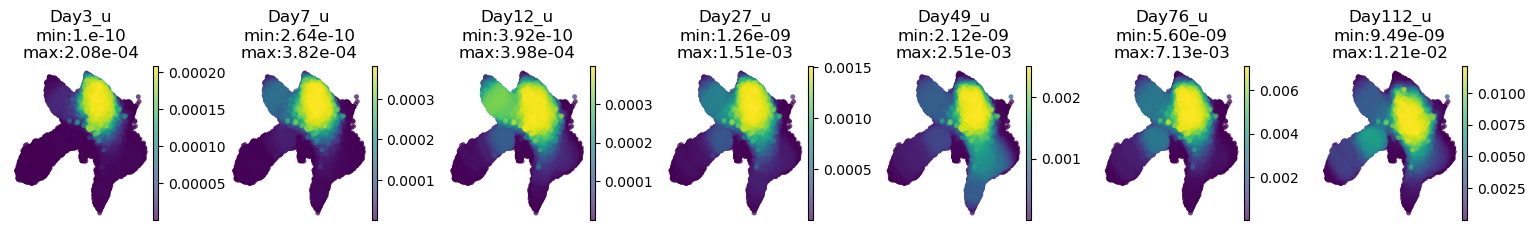

In [52]:
PINN.pl.params_in_umap(t7_ad, u_b, param='u', cell_of_t=False);

prediction of shape (7, 25948)


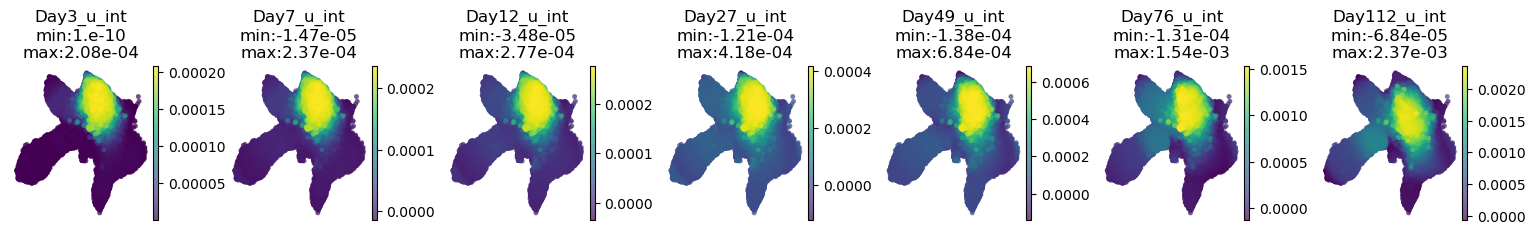

In [23]:
PINN.pl.params_in_umap(t7_ad, u_t_whole, param='u_int', cell_of_t=False);

# direct dudt

In [11]:
device = mlp_model.device

class Dudt(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, states):

        s = states[1]
        t_in = torch.full((s.shape[0],1), t.item()*5).float().to(device)

        with torch.set_grad_enabled(True):

            s.requires_grad_(True)
            t_in.requires_grad_(True)

            dudt, growth, drift, diffuse = self.model.equation(s, t_in)

            # set ds to zeros to fix cellstates
            ds = torch.zeros_like(s).float().to(device).requires_grad_(True)

        return (dudt, ds)

In [12]:
dudt =Dudt(mlp_model)

## define initital condition

In [16]:
# t_list
t_list = t7_ad.uns['pop']['t'][:n_timepoint] / 15

print(timepoints[:n_timepoint])
print(t_list)

[  3   7  12  27  49  76 112]
[0.2        0.46666667 0.8        1.8        3.26666667 5.06666667
 7.46666667]


In [23]:
u_t_ls = []
chunk_size= len(cellstate)//10

for i in range(0, len(cellstate), chunk_size):

    # feed initial condition in batch
    s0 = cellstate[i:i+chunk_size].to(device)
    tompos_u0 = torch.from_numpy(u_b[0, i:i+chunk_size]).float().to(device).requires_grad_()
    init_condition = (tompos_u0, s0)

    # doing integration
    u_t, s_t = odeint(
                    dudt,
                    init_condition,
                    torch.tensor(t_list).type(torch.float32).to(device),
                    atol=1e-5,
                    rtol=1e-5,
                    method='midpoint',
                    options = {'step_size': 0.1}
                )

    torch.cuda.empty_cache()

    u_t_ls.append(u_t.detach().cpu().numpy())
    del u_t, s_t
    torch.cuda.empty_cache()

In [24]:
u_t_whole = np.concatenate(u_t_ls, axis=1)

In [26]:
u_t_whole.shape

(7, 25948)

prediction of shape (7, 25948)


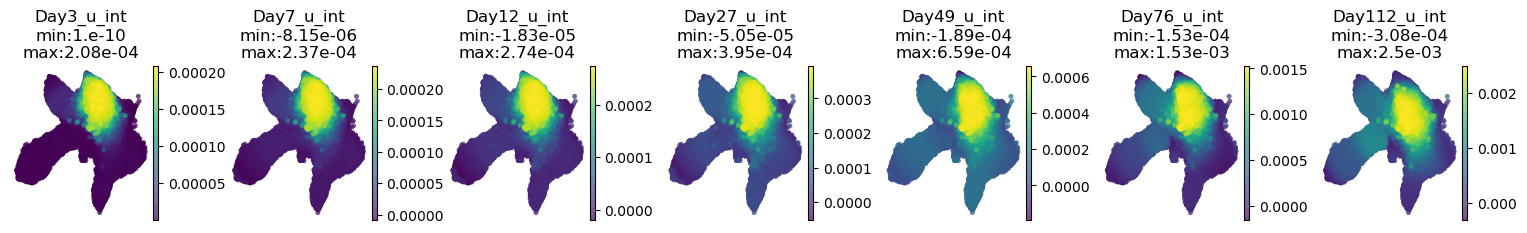

In [27]:
PINN.pl.params_in_umap(t7_ad, u_t_whole, param='u_int', cell_of_t=False);